# 7. Análisis multivariado (sección 2.4)

*Autores: María Carolina Cantillo Orozco (200179105) y Juan Camilo Oñoro Araujo (200177329)*

- Reducción de dimensionalidad exploratoria (**PCA**; t-SNE solo como
  herramienta visual, no inferencial).
- Outliers **multivariados** (distancia de Mahalanobis robusta e Isolation
  Forest).
- Estructura de grupos o subpoblaciones (clustering exploratorio con
  K-Means).

Se usan las variables físicas numéricas en la escala en que entrarían al
modelo (log1p en las asimétricas, estandarizadas). Todo con **train**.

In [1]:
# Celda de preparación: librerías, carga de train y construcción de la matriz
# numérica estandarizada Zs que usan todos los análisis del capítulo (PCA,
# outliers multivariados, clustering y t-SNE). Solo train, para no filtrar
# información de test a las decisiones del EDA.
import sys
import warnings
from pathlib import Path

# Raíz del libro (carpeta padre si se ejecuta desde notebooks/) para importar src.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore", category=FutureWarning)  # avisos de versión, no de resultados

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.covariance import MinCovDet
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from src import config as C
from src import espacial as S
from src import estadistica as E
from src import graficos as G
from src import particion as P

G.estilo()
C.aviso_sintetico()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
train = P.cargar_particion(solo="train")
# Variables que el cap. 5.5 decidió transformar con log1p.
dec = C.leer_decisiones()
num_log = dec.get("num_log", {}).get("valor", [])
# Solo las 8 variables físicas: las coordenadas se estudian aparte (cap. 8) y
# aquí interesa la estructura de las características de la vivienda.
vars_pca = [c for c in C.NUMERICAS if c in train]

# Misma escala que en el modelo: log1p en las asimétricas (si no, PCA y
# Mahalanobis quedarían dominados por unos pocos valores extremos de la cola).
Z = train[vars_pca].copy()
for c in num_log:
    if c in Z:
        Z[c] = np.log1p(Z[c].clip(lower=0))
# PCA, MCD, K-Means y t-SNE no aceptan NaN: imputación simple con la mediana.
Z = Z.fillna(Z.median())
# Estandarizar (media 0, desviación 1) es imprescindible: PCA y K-Means se
# basan en varianzas y distancias euclídeas, y sin escalar dominaría la
# variable con mayor rango (el área), no la más informativa.
Zs = StandardScaler().fit_transform(Z)
print(f"Matriz para el análisis multivariado: {Zs.shape[0]:,} filas × {Zs.shape[1]} variables")

Matriz para el análisis multivariado: 218,870 filas × 8 variables


## 7.1 PCA: varianza explicada y estructura

In [2]:
# PCA con todas las componentes para ver cómo se reparte la varianza y cuántas
# dimensiones "efectivas" tienen las variables físicas. Se aplican tres
# criterios: % de varianza acumulada (80 % y 90 %), Kaiser y participation ratio.
pca = PCA(random_state=C.SEED).fit(Zs)
var = pd.DataFrame({"varianza explicada": pca.explained_variance_ratio_,
                    "acumulada": np.cumsum(pca.explained_variance_ratio_),
                    "autovalor": pca.explained_variance_},
                   index=[f"PC{i + 1}" for i in range(len(vars_pca))])
# argmax sobre un booleano devuelve la primera posición True; +1 porque las
# componentes se numeran desde 1.
k80 = int(np.argmax(var["acumulada"] >= 0.80) + 1)
k90 = int(np.argmax(var["acumulada"] >= 0.90) + 1)
# Kaiser: con datos estandarizados cada variable aporta varianza 1, así que
# una componente con λ > 1 resume más que una variable original.
kaiser = int((var["autovalor"] > 1).sum())
# Participation ratio = (Σλ)² / Σλ²: vale p si la varianza se reparte por igual
# entre las p componentes y 1 si toda está en una; mide la dimensión efectiva.
pr = pca.explained_variance_.sum() ** 2 / (pca.explained_variance_ ** 2).sum()
print(f"Componentes para 80 % de varianza: {k80} | para 90 %: {k90} | criterio de Kaiser (λ>1): {kaiser}")
print(f"Dimensionalidad efectiva (participation ratio): {pr:.2f} de {len(vars_pca)} variables")
var

Componentes para 80 % de varianza: 5 | para 90 %: 6 | criterio de Kaiser (λ>1): 3
Dimensionalidad efectiva (participation ratio): 5.41 de 8 variables


,varianza explicada,acumulada,autovalor
PC1,0.288,0.288,2.302
PC2,0.233,0.521,1.864
PC3,0.125,0.646,1.002
PC4,0.121,0.767,0.966
PC5,0.107,0.874,0.855
PC6,0.060,0.933,0.479
PC7,0.042,0.976,0.336
PC8,0.024,1.000,0.196


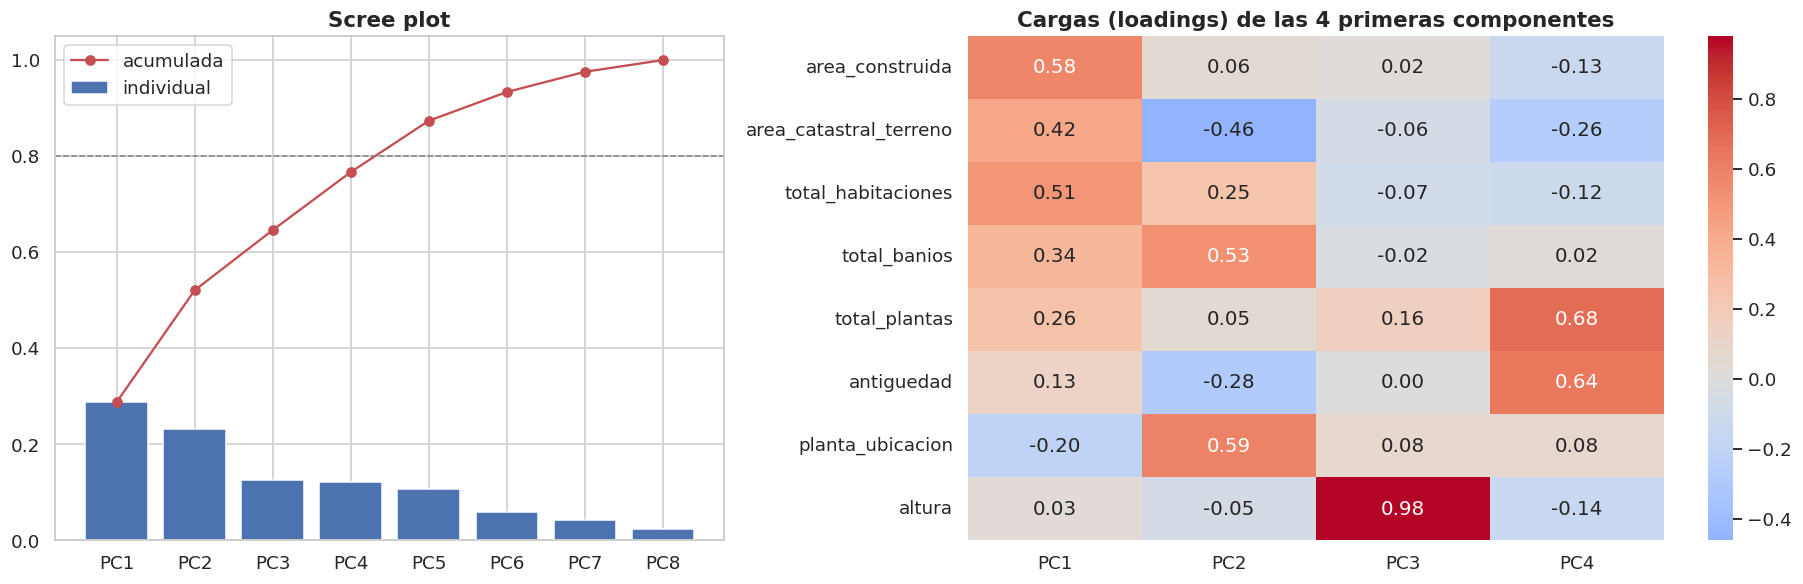

In [3]:
# Figura de dos paneles: (izq.) scree plot con la varianza de cada componente
# y la acumulada, con la línea de referencia del 80 %; (der.) mapa de calor de
# las cargas (loadings) de las 4 primeras componentes, que permite nombrarlas
# según qué variables pesan más y con qué signo.
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), gridspec_kw={"width_ratios": [1, 1.3]})
axes[0].bar(var.index, var["varianza explicada"], color="#4c72b0", label="individual")
axes[0].plot(var.index, var["acumulada"], "o-", color="#c44e52", label="acumulada")
axes[0].axhline(0.8, ls="--", color="grey", lw=1)
axes[0].set_title("Scree plot")
axes[0].legend()
# components_ tiene una fila por componente; se transpone para ver variables en filas.
cargas = pd.DataFrame(pca.components_[:4].T, index=vars_pca, columns=[f"PC{i + 1}" for i in range(4)])
sns.heatmap(cargas, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Cargas (loadings) de las 4 primeras componentes")
fig.tight_layout()
G.guardar(fig, "07_pca_scree_cargas")
plt.show()

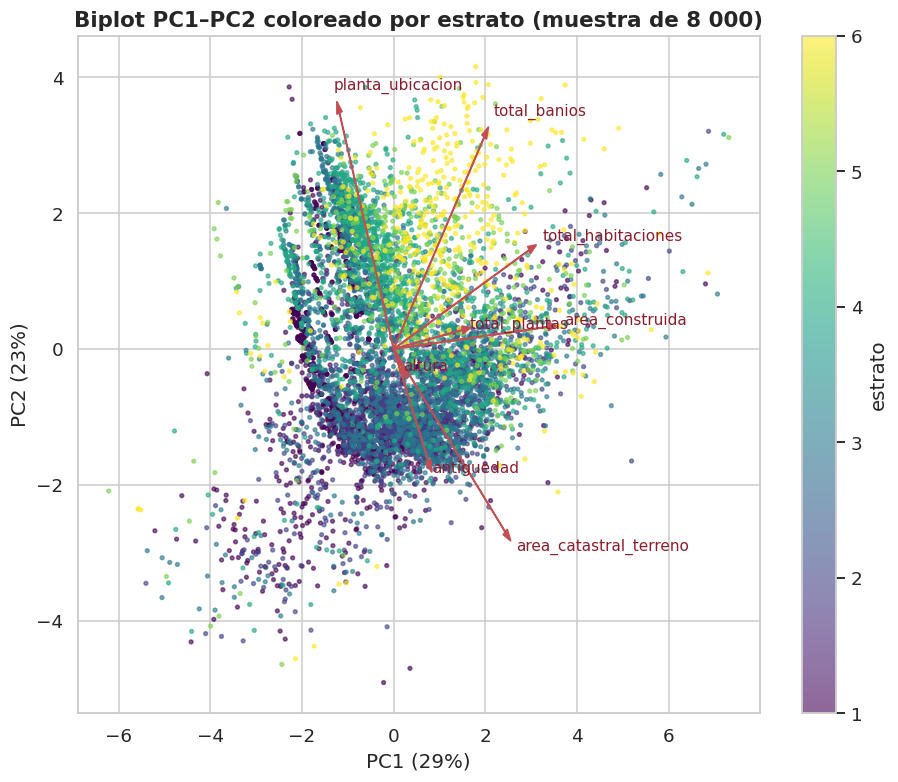

In [4]:
# Figura: biplot PC1–PC2. Los puntos son unidades coloreadas por estrato y las
# flechas rojas son las cargas de cada variable: indican hacia dónde crece
# cada variable en el plano y permiten ver qué región ocupa cada estrato.
# Muestra estratificada de 8 000 puntos para que el gráfico no se sature. La
# columna auxiliar _i guarda la posición original de cada fila, porque
# muestra_estratificada reinicia el índice y hace falta indexar Zs por posición.
idx = S.muestra_estratificada(train.assign(_i=np.arange(len(train))), 8000)["_i"].to_numpy()
pcs = pca.transform(Zs[idx])[:, :2]
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(pcs[:, 0], pcs[:, 1], c=train[C.OBJETIVO].to_numpy()[idx], cmap="viridis", s=6, alpha=0.6)
# Las cargas están en [−1, 1]; se reescalan al 80 % del rango de los puntos
# para que las flechas sean visibles sobre la nube (solo cambia la longitud).
escala = np.abs(pcs).max() * 0.8
for j, v in enumerate(vars_pca):
    ax.arrow(0, 0, pca.components_[0, j] * escala, pca.components_[1, j] * escala, color="#c44e52",
             width=0.01, head_width=0.12)
    # Etiqueta un 10 % más allá de la punta de la flecha para no taparla.
    ax.text(pca.components_[0, j] * escala * 1.1, pca.components_[1, j] * escala * 1.1, v, fontsize=10,
            color="#8b1e2d")
ax.set_xlabel(f"PC1 ({var.iloc[0, 0]:.0%})")
ax.set_ylabel(f"PC2 ({var.iloc[1, 0]:.0%})")
ax.set_title("Biplot PC1–PC2 coloreado por estrato (muestra de 8 000)")
plt.colorbar(sc, label="estrato")
G.guardar(fig, "07_biplot")
plt.show()

In [5]:
# Asociación de las 3 primeras componentes con el estrato. Se usa Spearman
# porque el estrato es ordinal (1–6) y la relación puede ser monótona pero no
# lineal. Responde si el eje de mayor varianza es también el más ligado al
# estrato (no tiene por qué: PCA es no supervisado).
pc_scores = pca.transform(Zs)[:, :3]
corr_pc = pd.DataFrame({f"PC{i + 1}": [stats.spearmanr(pc_scores[:, i], train[C.OBJETIVO])[0]]
                        for i in range(3)}, index=["Spearman con estrato"])
corr_pc

,PC1,PC2,PC3
Spearman con estrato,0.251,0.476,0.189


```{admonition} Interpretación
:class: note
- **Dimensionalidad.** PC1 explica 28.8 % y PC2 23.3 % (52.1 % entre las dos).
  Hacen falta **5 componentes para el 80 %** y 6 para el 90 %; el criterio de
  Kaiser retiene 3 y la dimensionalidad efectiva (participation ratio) es
  **5.41 de 8**. Hay algo de redundancia, pero moderada, coherente con VIF < 3
  (cap. 6): las variables físicas no se reducen a uno o dos ejes.
- **PC1 = "tamaño"**: cargas positivas en área construida (0.58),
  habitaciones (0.51), terreno (0.42) y baños (0.34).
- **PC2 = "apartamento moderno frente a casa con lote"**: positiva en piso de
  ubicación (0.59) y baños (0.53), negativa en terreno (−0.46) y antigüedad
  (−0.28). Es un eje de tipología: unidades en altura, más nuevas y con más
  baños frente a casas antiguas con terreno propio.
- **PC3 es prácticamente `altura` sola** (carga 0.98): recoge la poca
  variación de una variable casi constante, y PC4 combina plantas (0.68) y
  antigüedad (0.64).
- **Relación con el estrato:** es **PC2** y no PC1 la más asociada
  (Spearman 0.476 frente a 0.251). PC3 tiene Spearman 0.189 pese a ser casi
  solo `altura` (Spearman 0.048 con el estrato, cap. 6): como `altura` vale 3
  en más del 99 % de las filas, el orden de PC3 dentro de esa masa lo fijan
  sus cargas pequeñas (plantas, piso). Distingue mejor el estrato el *tipo* de
  vivienda (apartamento moderno en altura) que su tamaño. No se usa PCA
  dentro del modelo base: las variables originales son interpretables y n/p
  es enorme.
```

## 7.2 Outliers multivariados

**Mahalanobis robusta:** la distancia de Mahalanobis clásica usa la media y
la covarianza, que los propios outliers distorsionan; por eso se estima con
el **determinante de covarianza mínima** (MCD) sobre una submuestra y se
marca como outlier a quien supera el cuantil 0.999 de una χ² con p grados de
libertad. **Isolation Forest** no asume forma elíptica: aísla puntos raros
con particiones aleatorias. Se fija `contamination=0.01` (1 %) para que ambos
métodos marquen una proporción comparable; con `"auto"` el umbral depende de
la forma de los datos y en variables discretas puede marcar demasiado.

In [6]:
# Detección de outliers multivariados con dos criterios complementarios:
# Mahalanobis robusta (supone forma elíptica) e Isolation Forest (no la supone).
# Ambos se AJUSTAN en una submuestra aleatoria de 30 000 filas (el MCD es
# costoso y con 30 000 la estimación de centro y covarianza ya es estable) y
# luego se APLICAN a todas las filas de train.
rng = np.random.default_rng(C.SEED)
sub = rng.choice(len(Zs), min(30_000, len(Zs)), replace=False)
# Con variables discretas (conteos con muchos empates) el algoritmo C-step de
# MinCovDet emite avisos "Determinant has increased": son numéricos, no cambian
# el resultado de forma apreciable y se silencian para no ensuciar el libro.
import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Determinant has increased", category=RuntimeWarning)
    # MCD estima centro y covarianza con el subconjunto de puntos de menor
    # determinante de covarianza, de modo que los outliers no inflan la
    # covarianza ni se "esconden" (efecto máscara de la Mahalanobis clásica).
    # support_fraction=0.9: usa el 90 % más central, es decir, tolera hasta un
    # 10 % de contaminación; es más estable con variables discretas que el
    # valor por defecto (~50 %), que con tantos empates puede dar una
    # covarianza casi singular.
    mcd = MinCovDet(random_state=C.SEED, support_fraction=0.9).fit(Zs[sub])
d2 = mcd.mahalanobis(Zs)  # distancia de Mahalanobis AL CUADRADO de cada fila
# Bajo normalidad multivariada d² ~ χ² con p = 8 grados de libertad; el
# cuantil 0.999 deja fuera, en teoría, solo el 0.1 % de puntos "normales".
umbral = stats.chi2.ppf(0.999, df=Zs.shape[1])
out_maha = d2 > umbral
# Isolation Forest: 200 árboles para estabilizar el puntaje de anomalía;
# contamination=0.01 fija el umbral para marcar ~1 % de filas, una proporción
# comparable a la de Mahalanobis. n_jobs=-1 usa todos los núcleos.
iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=C.SEED, n_jobs=-1).fit(Zs[sub])
out_iso = iso.predict(Zs) == -1  # predict devuelve −1 para anomalías y 1 para normales
res = pd.DataFrame({
    "% outliers": [100 * out_maha.mean(), 100 * out_iso.mean(), 100 * (out_maha & out_iso).mean()],
}, index=["Mahalanobis robusta (χ² 0.999)", "Isolation Forest", "ambos"])
# Jaccard = |ambos| / |alguno|: cuánto coinciden los dos conjuntos de outliers
# (max(1, ...) evita dividir por cero si ninguno marcara nada).
print(f"Coincidencia (Jaccard) entre métodos: {(out_maha & out_iso).sum() / max(1, (out_maha | out_iso).sum()):.2f}")
res

Coincidencia (Jaccard) entre métodos: 0.20


,% outliers
Mahalanobis robusta (χ² 0.999),2.439
Isolation Forest,0.935
ambos,0.571


In [7]:
# ¿Los outliers multivariados se reparten igual entre estratos? Se compara la
# distribución de estrato (%) de las filas marcadas por AMBOS métodos (las
# más claramente atípicas) con la del resto. Si se concentran en algunas
# clases, eliminarlos sesgaría la muestra de entrenamiento.
comp = pd.concat({
    "outlier (ambos)": train.loc[out_maha & out_iso, C.OBJETIVO].value_counts(normalize=True),
    "resto": train.loc[~(out_maha & out_iso), C.OBJETIVO].value_counts(normalize=True),
}, axis=1).sort_index().fillna(0).mul(100)  # fillna(0): estratos sin outliers
comp.index = [C.NOMBRES_CLASES[i] for i in comp.index]
print("Distribución de estrato en outliers multivariados vs. resto (%):")
comp

Distribución de estrato en outliers multivariados vs. resto (%):


,outlier (ambos),resto
1 Bajo-bajo,11.040,25.625
2 Bajo,14.800,19.895
3 Medio-bajo,32.000,25.949
4 Medio,16.880,16.856
5 Medio-alto,11.920,6.057
6 Alto,13.360,5.617


In [8]:
# Perfil de los outliers: mediana de cada variable en escala ORIGINAL (m²,
# conteos, años) para poder interpretar qué tipo de unidad son y juzgar si
# parecen errores de registro o combinaciones raras pero válidas.
perfil = pd.concat({"outliers": train.loc[out_maha & out_iso, vars_pca].median(),
                    "resto": train.loc[~(out_maha & out_iso), vars_pca].median()}, axis=1)
print("Mediana de cada variable:")
perfil

Mediana de cada variable:


,outliers,resto
area_construida,92.500,76.000
area_catastral_terreno,255.900,70.755
total_habitaciones,0.000,3.000
total_banios,0.000,1.000
total_plantas,1.000,1.000
antiguedad,16.000,16.000
planta_ubicacion,1.000,1.000
altura,3.000,3.000


```{admonition} Interpretación y decisión
:class: note
- Mahalanobis robusta marca 2.44 % de train e Isolation Forest 0.94 % (cerca
  del 1 % fijado con `contamination`, que se calibra en la submuestra de
  ajuste). Solo **0.57 %** coincide en ambos, y la coincidencia es baja
  (Jaccard = 0.20): los dos métodos miran cosas distintas (forma elíptica
  frente a aislamiento), así que "outlier" depende mucho del criterio.
- Los marcados por ambos son **combinaciones raras, no errores evidentes**:
  mediana de **0 habitaciones y 0 baños**, 92.5 m² construidos y **256 m² de
  terreno** (frente a 3, 1, 76 y 71 en el resto). Parecen lotes con
  construcciones menores o unidades sin espacios habitables registrados
  (p. ej. en obra o con ficha incompleta). Las reglas de limpieza del cap. 1
  no los tocan: los ceros en habitaciones y baños quedaron como limitación
  abierta (cap. 1.7.3).
- Están **sobre-representados en estratos altos**: el 25.3 % son estratos
  5–6, frente al 11.7 % del resto (y solo 11.0 % son estrato 1 frente a
  25.6 %). Eliminarlos quitaría justo casos de las clases minoritarias.
- **Decisión:** se conservan; su influencia ya se limita con log1p +
  winsorización dentro del Pipeline.
```

In [9]:
# Se registra la decisión de conservar los outliers con su justificación
# cuantitativa (qué % son estrato 5–6 frente al resto), para que el capítulo
# del modelo la lea desde decisiones_eda.json.
ambos = out_maha & out_iso
# Si no hubiera ningún outlier común, el % queda en NaN en lugar de fallar.
pct_altos_out = 100 * train.loc[ambos, C.OBJETIVO].isin([5, 6]).mean() if ambos.any() else float("nan")
pct_altos_resto = 100 * train.loc[~ambos, C.OBJETIVO].isin([5, 6]).mean()
C.guardar_decision("outliers_multivariados", "conservar (sin eliminar filas)",
                   f"{100 * ambos.mean():.2f}% marcados por ambos métodos; {pct_altos_out:.0f}% de ellos son "
                   f"estrato 5-6 (vs {pct_altos_resto:.0f}% en el resto): eliminarlos sesgaría las clases "
                   "altas (cap. 7.2).")

[decisión registrada] outliers_multivariados = conservar (sin eliminar filas)
   motivo: 0.57% marcados por ambos métodos; 25% de ellos son estrato 5-6 (vs 12% en el resto): eliminarlos sesgaría las clases altas (cap. 7.2).


## 7.3 Subpoblaciones: clustering exploratorio

K-Means sobre las variables estandarizadas (submuestra de 30 000), eligiendo
k con el coeficiente de silueta. El objetivo **no** es modelar (eso es la
tesis) sino ver si hay grupos naturales y cómo se relacionan con el estrato.

In [10]:
# Elección de k para K-Means con el coeficiente de silueta (compara la
# distancia media de cada punto a su propio clúster con la del clúster vecino;
# va de −1 a 1 y valores altos indican grupos compactos y separados). Se usa
# la misma submuestra de 30 000 filas que en los outliers.
Xs = Zs[sub]
sil = {}
for k in range(2, 9):  # k de 2 a 8
    # n_init=5 reinicios con centroides distintos para no quedarse en un
    # mínimo local; es suficiente para comparar k y más rápido que 10.
    km = KMeans(n_clusters=k, n_init=5, random_state=C.SEED).fit(Xs)
    # La silueta cuesta O(n²) en distancias: se calcula sobre 8 000 puntos.
    sil[k] = silhouette_score(Xs, km.labels_, sample_size=8000, random_state=C.SEED)
sil = pd.Series(sil, name="silueta")
k_opt = int(sil.idxmax())
print(f"k con mayor silueta: {k_opt}")
sil.to_frame().T

k con mayor silueta: 4


,2,3,4,5,6,7,8
silueta,0.236,0.245,0.250,0.244,0.228,0.205,0.212


In [11]:
# Modelo final de K-Means con el k elegido (más reinicios, n_init=10, para una
# solución más estable) y su relación con el estrato: composición de estratos
# por clúster (% por fila), tamaño, condición de predio predominante y V de
# Cramér clúster–estrato como medida resumen de asociación.
km = KMeans(n_clusters=k_opt, n_init=10, random_state=C.SEED).fit(Xs)
t_sub = train.iloc[sub]  # filas de train correspondientes a la submuestra
tab = pd.crosstab(km.labels_, t_sub[C.OBJETIVO], normalize="index").mul(100)
tab.columns = [C.NOMBRES_CLASES[c] for c in tab.columns]
tab["n"] = pd.Series(km.labels_).value_counts().sort_index().to_numpy()
# Moda de condicion_predio en cada clúster (PH, NPH, informal) para nombrarlo.
tab["condición predominante"] = [t_sub["condicion_predio"][km.labels_ == g].mode().iloc[0] for g in tab.index]
# reset_index alinea el estrato con las etiquetas (índice 0..n−1); sin él,
# pandas cruzaría por el índice original de train y la tabla saldría mal.
v_cl = E.cramers_v(pd.Series(km.labels_), t_sub[C.OBJETIVO].reset_index(drop=True))["V"]
print(f"V de Cramér clúster ~ estrato: {v_cl:.3f}")
tab

V de Cramér clúster ~ estrato: 0.308


,1 Bajo-bajo,2 Bajo,3 Medio-bajo,4 Medio,5 Medio-alto,6 Alto,n,condición predominante
row_0,,,,,,,,
0,19.758,3.007,27.369,31.448,9.120,9.298,10077,PH_Unidad_Predial
1,37.436,34.138,21.992,4.765,1.175,0.494,12341,NPH
2,90.698,0.000,0.000,9.302,0.000,0.000,86,PH_Unidad_Predial
3,12.220,19.891,28.655,18.810,10.472,9.952,7496,NPH


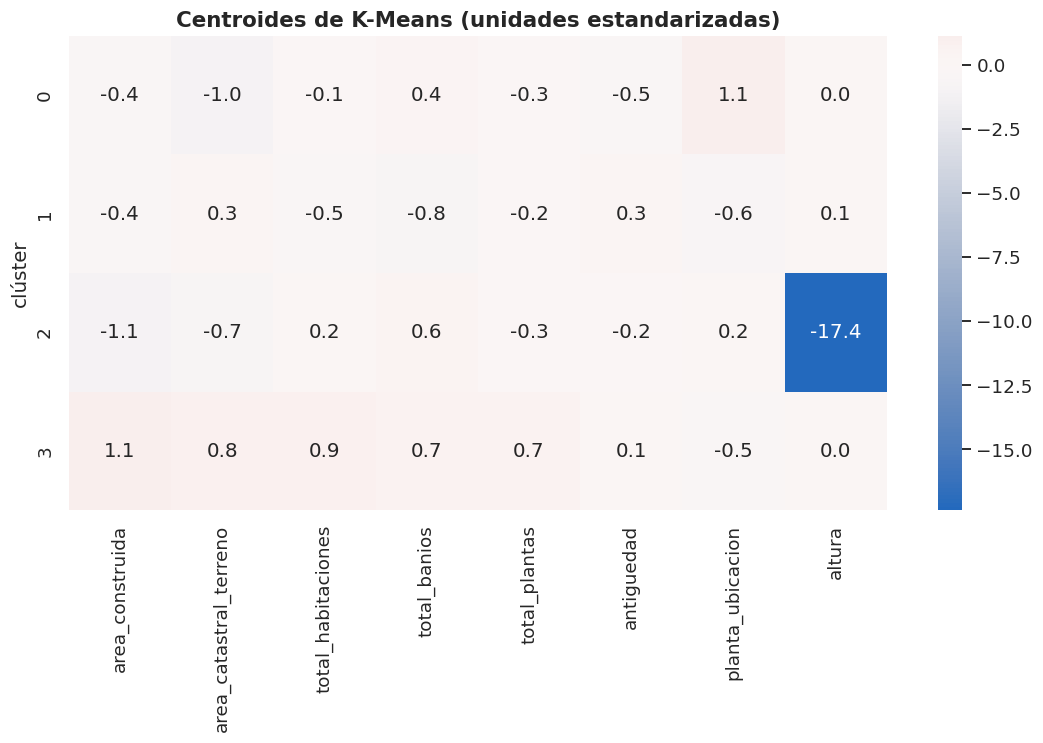

In [12]:
# Figura: mapa de calor de los centroides de K-Means en unidades estandarizadas
# (desviaciones respecto a la media de train, tras log1p). Rojo = por encima
# de la media, azul = por debajo; sirve para caracterizar cada clúster
# (p. ej. "casas grandes con lote" frente a "apartamentos en altura").
perfil_cl = pd.DataFrame(km.cluster_centers_, columns=vars_pca)
fig, ax = plt.subplots(figsize=(12, 0.9 * k_opt + 2))
sns.heatmap(perfil_cl, annot=True, fmt=".1f", cmap="vlag", center=0, ax=ax)
ax.set_ylabel("clúster")
ax.set_title("Centroides de K-Means (unidades estandarizadas)")
G.guardar(fig, "07_kmeans_centroides")
plt.show()

### t-SNE (solo visual)

t-SNE conserva vecindades locales pero **distorsiona distancias globales y
tamaños de grupos**: no se interpreta cuantitativamente.

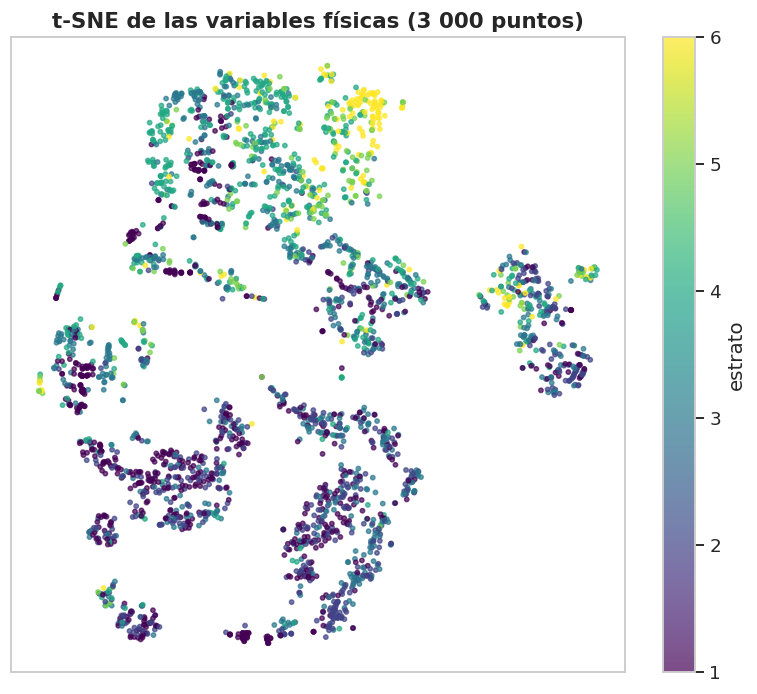

In [13]:
# Figura: proyección t-SNE en 2D coloreada por estrato. Es SOLO visual: t-SNE
# preserva vecindades locales pero no distancias globales ni tamaños de grupo,
# así que no se usa para medir nada ni entra al modelo.
# 3 000 puntos al azar (t-SNE es costoso, del orden de n² o n·log n por
# iteración); el generador rng continúa la secuencia fijada con C.SEED.
s3 = rng.choice(len(Zs), min(3000, len(Zs)), replace=False)
# perplexity=40 ≈ número efectivo de vecinos considerado (rango usual 5–50);
# init="pca" da una disposición inicial más estable y reproducible que la
# aleatoria y conserva mejor la estructura global.
emb = TSNE(n_components=2, perplexity=40, random_state=C.SEED, init="pca").fit_transform(Zs[s3])
fig, ax = plt.subplots(figsize=(9, 7.5))
sc = ax.scatter(emb[:, 0], emb[:, 1], c=train[C.OBJETIVO].to_numpy()[s3], cmap="viridis", s=8, alpha=0.7)
plt.colorbar(sc, label="estrato")
ax.set_title("t-SNE de las variables físicas (3 000 puntos)")
# Se ocultan los ejes: las coordenadas de t-SNE no tienen unidades interpretables.
ax.set_xticks([])
ax.set_yticks([])
G.guardar(fig, "07_tsne")
plt.show()

```{admonition} Interpretación
:class: note
- **K-Means** elige k = 4, pero la silueta es baja y casi igual en todos
  los k (0.205–0.250; k = 3, 4 y 5 quedan en 0.244–0.250): no hay grupos
  naturales bien separados, sino un continuo de tipologías.
- Los clústeres se alinean sobre todo con la **tipología**: dos grupos NPH
  (casas pequeñas y casas grandes), uno PH (apartamentos) y un grupo
  diminuto de 86 unidades PH con `altura` anómala (centroide de −17.4
  desviaciones, es decir, altura ≈ 1 frente al 3 casi universal, cap. 5),
  91 % estrato 1. Con el estrato la asociación es apenas moderada
  (V = 0.31):
  - clúster 1 (casas pequeñas, NPH, n = 12 341; área, habitaciones y baños
    por debajo de la media): 72 % estratos 1–2;
  - clúster 3 (casas grandes, NPH, n = 7 496; área, terreno, habitaciones,
    baños y plantas por encima de la media): mezcla de todos los estratos,
    centrada en 2–4 (con 20 % en 5–6);
  - clúster 0 (apartamentos PH, n = 10 077; piso alto, poco terreno, más
    nuevos): 59 % en estratos 3–4 y 18 % en 5–6, pero también 20 % en
    estrato 1.
- Dentro de cada tipología hay varios estratos: las variables físicas
  separan razonablemente los extremos, pero no las clases intermedias.
- **Anticipa el resultado del modelo:** hace falta información que las
  variables físicas no tienen, y esa información es la **localización**
  (cap. 8).
```